## Light Bulb & Resistor

### Characteristic
A simple light bulb has a nonlinear current vs voltage characteristic.

#### Resistance vs current
As a first step, we investigate how the resistance depends on the current. As can be seen in the diagram below, the data hints at a linear relation:

$R(I) = R_0 + k I$

We therefore fit a linear function to the data.

In [1]:
import numpy as np

# add your own data below

# voltage
V = np.array([23.97,22.02,20.05,18.01,16.03,14.01,12.02,10.01,8.00,6.03,4.010,2.002]) # voltage values in V
dV = 0.03 # voltage uncertainty in V

# current
I = np.array([120.7, 115.2, 108.5, 101.8, 96.3, 87.5, 80.0, 71.7, 62.6, 52.9, 41.5, 27.6]) #current values in mA
dI = 0.5 # current uncertainty in mA

# resistance and uncertainty
# ignoring the first point since it is zero and would cause division by zero
R = V[1:] / I[1:] # resistance values in ohms

# uncertainty in resistance using max/min method
Vmax = V + dV
Imin = I - dI

Rmax = Vmax[1:]/Imin[1:]
dR = Rmax - R

# # uncertainty in resistance using error propagation
# dR = R * (dV/V + dI/I) # resistance uncertainty in ohms

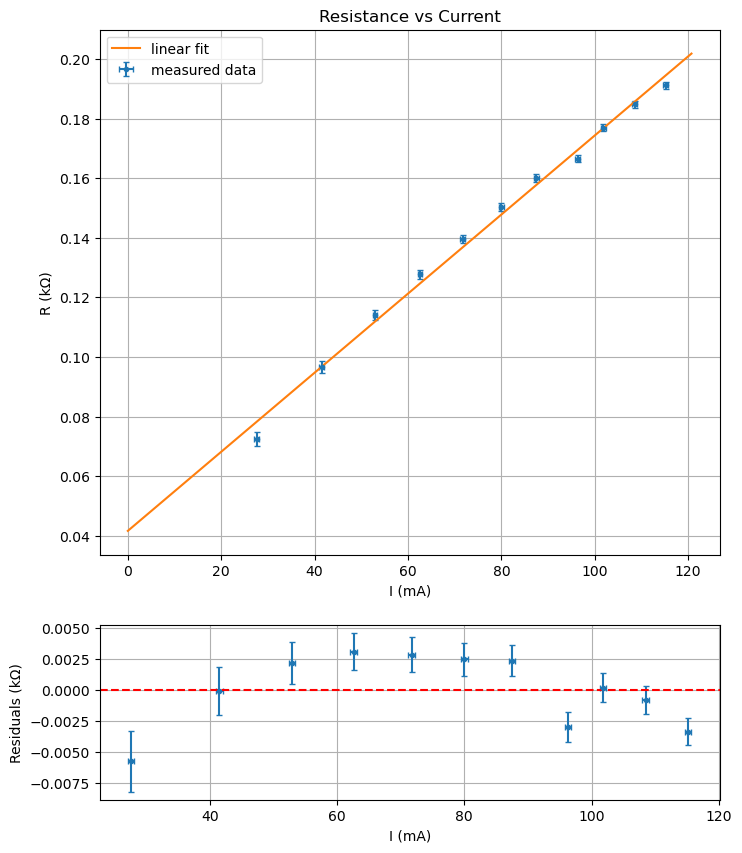

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# define linear model for fitting
def linear_model(x, k, R0):
    return k * x + R0

# calculate linear fit parameters and their uncertainties
coeff, pcov = curve_fit(linear_model, I[1:], R)
k_lin, R0_lin = coeff
dk_lin, dR0_lin = np.sqrt(np.diag(pcov))

# calculate fitted values and residuals
I_range = np.linspace(0, max(I), 100)
R_fit = linear_model(I_range, k_lin, R0_lin)

res_lin = R - linear_model(I[1:], k_lin, R0_lin)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(I[1:], R, xerr=dI, yerr=dR, fmt='.', capsize=2, label='measured data')
ax1.plot(I_range, R_fit, label='linear fit')
ax1.set_title('Resistance vs Current')
ax1.set_xlabel('I (mA)')
ax1.set_ylabel('R (kΩ)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(I[1:], res_lin, xerr=dI, yerr=dR, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('I (mA)')
ax2.set_ylabel('Residuals (kΩ)')
ax2.grid(True)
plt.show()

##### Discussion

Looks pretty good, only the first data point is a bit off

In [3]:
print(f"Linear fit parameters: k = ({k_lin*1000:.2f} ± {dk_lin*1000:.2f}) Ω/mA, R0 = ({R0_lin*1000:.0f} ± {dR0_lin*1000:.0f}) Ω")

Linear fit parameters: k = (1.33 ± 0.03) Ω/mA, R0 = (42 ± 3) Ω


#### Current vs Voltage

$R_L = R_0 + k \cdot I, V_L = R_L \cdot I = (R_0 + k I) \cdot I = R_0 I + k I^2 => I = \frac{-R_0 +- \sqrt{R_0^2 + 4k V_L}}{2 k}$

/tmp/ipykernel_7794/394021664.py:2: RuntimeWarning: invalid value encountered in sqrt
  return (-R0 + np.sqrt(R0 * R0 + 4 * k * x))/(2 * k)


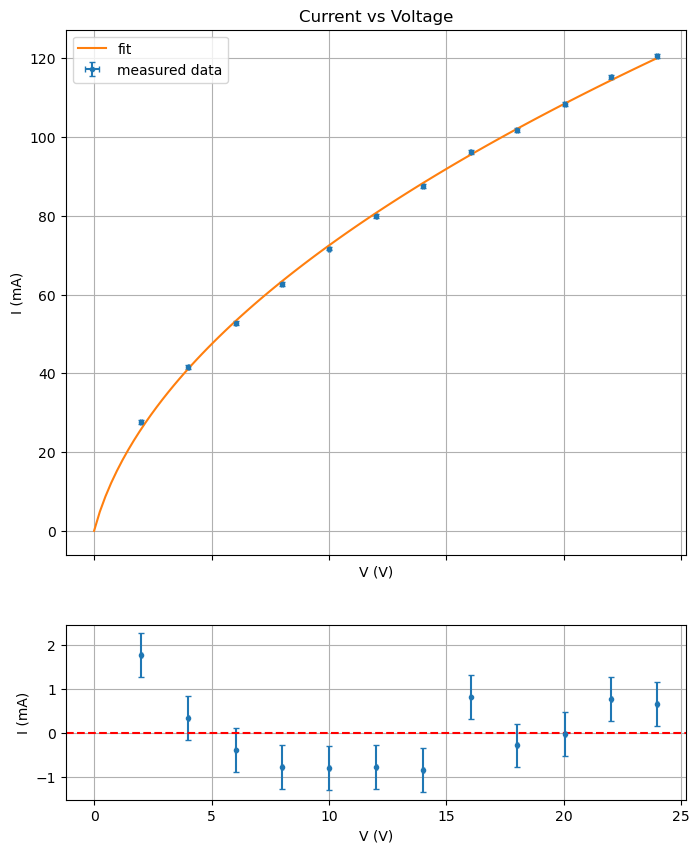

In [5]:
def sqrt_model(x, k, R0):
    return (-R0 + np.sqrt(R0 * R0 + 4 * k * x))/(2 * k)

# calculate square root fit parameters and their uncertainties
popt, pcov = curve_fit(sqrt_model, V, I)
k_sqrt, R0_sqrt = popt
dk_sqrt, dR0_sqrt = np.sqrt(np.diag(pcov))

# calculate fitted values and residuals for square root model
V_range = np.linspace(0, max(V), 100)
I_fit = sqrt_model(V_range, k_sqrt, R0_sqrt)
res_sqrt = I - sqrt_model(V, k_sqrt, R0_sqrt)

fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax1, ax2 = ax
ax1.errorbar(V, I, xerr=dV, yerr=dI, fmt='.', capsize=2, label='measured data')
ax1.plot(V_range, I_fit, label='fit')
ax1.set_title('Current vs Voltage')
ax1.set_xlabel('V (V)')
ax1.set_ylabel('I (mA)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(V, res_sqrt, xerr=dV, yerr=dI, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('V (V)')
ax2.set_ylabel('I (mA)')
ax2.grid(True)

plt.show()

##### Discussion
Very good fit, our theory seems to match pretty solidly

In [6]:
print(f"square root fit parameters: k = ({k_sqrt*1000:.2f} ± {dk_sqrt*1000:.2f}) Ω/mA, R0 = ({R0_sqrt*1000:.0f} ± {dR0_sqrt*1000:.0f}) Ω")

square root fit parameters: k = (1.30 ± 0.03) Ω/mA, R0 = (44 ± 3) Ω


### Series circuit

$\frac{-R_0 + \sqrt{R_0^2 + 4k V_L}}{2 k} = \frac {V_0 - V_L} R$

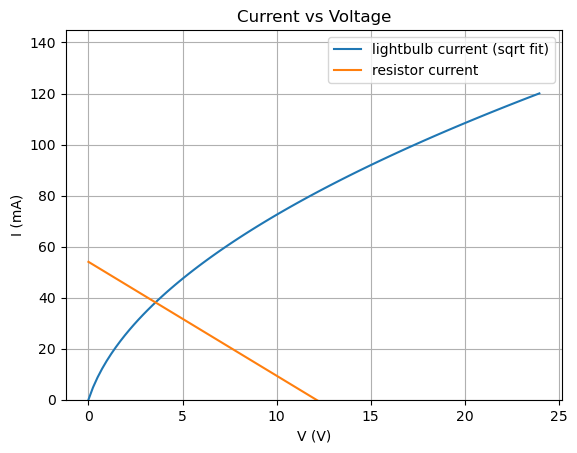

In [8]:
V0 = 3.54 + 8.57 # total voltage in V
R = 0.2241 # resistance of resistor in kohms

V_range = np.linspace(0, max(V), 100)

IL = sqrt_model(V_range, k_sqrt, R0_sqrt) # define square root fit for current through the lightbulb
IR = (V0 - V_range) / R # define current through the resistor using Ohm's law

fig, ax = plt.subplots()
ax.plot(V_range, IL, label='lightbulb current (sqrt fit)')
ax.plot(V_range, IR, label='resistor current')
ax.set_title('Current vs Voltage')
ax.set_xlabel('V (V)')
ax.set_ylabel('I (mA)')
ax.set_ylim(0, max(I)*1.2)
ax.grid(True)
ax.legend()


Intersection at y = ~35-40 is very close to the measured current at 38.3. This is expected, as the intersection point is the point where the currents are the same, as is the case in a circuit in series, and we can solve this for the partial current through the light bulb, and from that get the current through the resistor too.

In [14]:
from scipy.optimize import root_scalar

def current_diff(V, k, R0, V0, R):
    # return current through lightbulb minus current resistor
    return sqrt_model(V, k, R0) - (V0 - V) / R

x0 = 3.6 # add initial guess for voltage across the lightbulb when currents are equal, based on the plot

sol = root_scalar(current_diff, args=(k_sqrt, R0_sqrt, V0, R), x0=x0)
VL_num = sol.root
IL_num = sqrt_model(VL_num, k_sqrt, R0_sqrt)
IR_num = (V0 - VL_num) / R

print(f"Voltage across the lightbulb when currents are equal: {VL_num:.2f} V")
print(f"Current through the lightbulb at this voltage: {IL_num:.2f} mA")
print(f"Current through the resistor at this voltage: {IR_num:.2f} mA")

Voltage across the lightbulb when currents are equal: 3.56 V
Current through the lightbulb at this voltage: 38.13 mA
Current through the resistor at this voltage: 38.13 mA


*Add discussion*

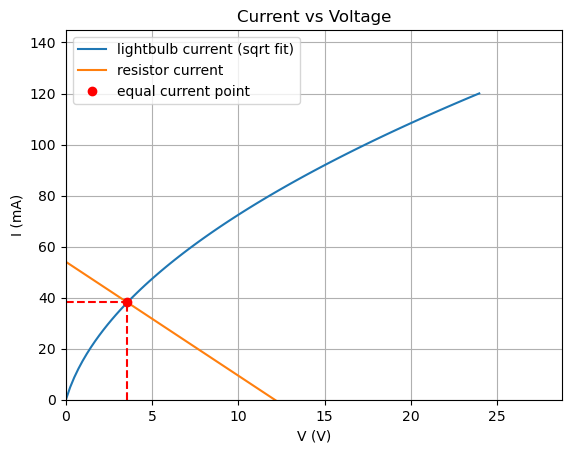

In [15]:
fig, ax = plt.subplots()
ax.plot(V_range, IL, label='lightbulb current (sqrt fit)')
ax.plot(V_range, IR, label='resistor current')
ax.plot(VL_num, IL_num, 'ro', label='equal current point')
ax.hlines(IL_num, 0, VL_num, color='red', linestyle='--')
ax.vlines(VL_num, 0, IL_num, color='red', linestyle='--')
ax.set_title('Current vs Voltage')
ax.set_xlabel('V (V)')
ax.set_ylabel('I (mA)')
ax.set_ylim(0, max(I)*1.2)
ax.set_xlim(0, max(V)*1.2)
ax.grid(True)
ax.legend()

plt.show()

In [25]:
V0 = 12.1 # total voltage in V
R = np.array([0.0992, 0.1512, 0.2241, 0.4720, 0.679]) # resistance of resistor in kohms
eI = np.array([])

V_range = np.linspace(0, max(V), 100)

IL = sqrt_model(V_range, k_sqrt, R0_sqrt) # define square root fit for current through the lightbulb
for r in R:
    IR = (V0 - V_range) / r # define current through the resistor using Ohm's law
    sol = root_scalar(current_diff, args=(k_sqrt, R0_sqrt, V0, r), x0=x0)
    VL_num = sol.root
    IL_num = sqrt_model(VL_num, k_sqrt, R0_sqrt)
    IR_num = (V0 - VL_num) / r
    print(f"For resistance {r}:")
    print(f"Voltage: {VL_num:.2f} V")
    print(f"Current lightbulb = {IL_num:.2f} = current resistor = {IR_num:.2f} mA")
    print("")

For resistance 0.0992:
Voltage across the lightbulb when currents are equal: 6.54 V
Current lightbulb = 56.05 = current resistor = 56.05 mA

For resistance 0.1512:
Voltage across the lightbulb when currents are equal: 4.96 V
Current lightbulb = 47.19 = current resistor = 47.19 mA

For resistance 0.2241:
Voltage across the lightbulb when currents are equal: 3.56 V
Current lightbulb = 38.11 = current resistor = 38.11 mA

For resistance 0.472:
Voltage across the lightbulb when currents are equal: 1.62 V
Current lightbulb = 22.21 = current resistor = 22.21 mA

For resistance 0.679:
Voltage across the lightbulb when currents are equal: 1.06 V
Current lightbulb = 16.26 = current resistor = 16.26 mA



### Analysis
Currents fit real values very well, the partial voltages are okay, but do have a good bit of error. (Also we seem to have (partially) switched around the V_R and V_L)

### Additional Exercises
After setting up and solving the appropriate system of equations, we get V_R = ~5.07V for the example circuit. TODO: add the other partial votlages and currents